In [5]:
import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import warnings
from sklearn.decomposition import FastICA
from scipy.stats import pearsonr
from PyEMD import CEEMDAN
from scipy.signal import hilbert

warnings.filterwarnings('ignore')

# Konfigurasi Plot
plt.rcParams['figure.figsize'] = (15, 4)
plt.rcParams['axes.grid'] = True

# --- KONFIGURASI PATH DINAMIS ---
# Karena notebook di: src/pipelines/2_feature_extraction/
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '../../../'))
DATASET_DIR = os.path.join(PROJECT_ROOT, 'dataset')
DATASET_CSV = os.path.join(DATASET_DIR, 'cleaned_transcript_mapping.csv')
RAW_DATA_PATH = os.path.join(DATASET_DIR, 'raw')

# Mendaftarkan modul asli model Anda ke sistem
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src/model'))
from misc.tokenizer import CharTokenizer
import misc.beam_decoder_char as beam_decoder_char
from model import ConformerTransducer

EEG_CHANNELS = ['EEG.AF3', 'EEG.F7', 'EEG.F3', 'EEG.FC5', 'EEG.T7', 
                'EEG.P7', 'EEG.O1', 'EEG.O2', 'EEG.P8', 'EEG.T8', 
                'EEG.FC6', 'EEG.F4', 'EEG.F8', 'EEG.AF4']

# Konfigurasi diselaraskan dengan all_train_1.py
CONFIG = {
    'input_dim': 14 * 65,
    'encoder_dim': 128,
    'decoder_dim': 128,
    'joint_dim': 128,
    'vocab_size': None, # Akan diisi otomatis oleh Tokenizer
    'sample_rate': 256,
    'hop_length': 8,      
    'win_length': 16,
    'f_min': 0.2,
    'f_max': 45.0,
    'start_imf': 2,
    'num_imfs': 4,         
    'ceemdan_trials': 15, # Kurangi trials di notebook agar cepat 
    'n_freq_bins': 65,
    'encoder_dropout': 0.2, 
    'decoder_dropout': 0.2
}

In [6]:
def split_dataset_by_sentence(df, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2, seed=42):
    np.random.seed(seed)
    unique_sentences = df['sentence'].unique()
    n_unique = len(unique_sentences)
    
    train_count = int(n_unique * train_ratio)
    val_count = int(n_unique * val_ratio)
    
    shuffled_sentences = np.random.permutation(unique_sentences)
    train_sentences = set(shuffled_sentences[:train_count])
    val_sentences = set(shuffled_sentences[train_count:train_count+val_count])
    
    df['split'] = df['sentence'].apply(
        lambda x: 'train' if x in train_sentences else ('val' if x in val_sentences else 'test')
    )
    return df

def load_safe_eeg(file_id, subject, gender):
    search_pattern = os.path.join(RAW_DATA_PATH, gender, subject, 'csv', f"{file_id}_*.bp.csv")
    files = glob.glob(search_pattern)
    if not files: return None
    try:
        df = pd.read_csv(files[0], skiprows=1, usecols=lambda c: c in EEG_CHANNELS, low_memory=False)
        df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
        return df[EEG_CHANNELS].values
    except Exception as e:
        return None

df_map = pd.read_csv(DATASET_CSV)
df_map = split_dataset_by_sentence(df_map, seed=42)

sample_data = {}
for split_name in ['train', 'val', 'test']:
    split_rows = df_map[df_map['split'] == split_name]
    for _, row in split_rows.iterrows():
        signal = load_safe_eeg(str(row['id']), str(row['subject']), str(row['gender']))
        if signal is not None and signal.shape[0] > 100:
            sample_data[split_name] = {'id': row['id'], 'sentence': row['sentence'], 'signal': signal}
            print(f"[{split_name.upper()}] Teks: '{row['sentence']}' | Shape: {signal.shape}")
            break

raw_eeg = sample_data['train']['signal']
target_sentence = sample_data['train']['sentence']

[TRAIN] Teks: 'siapa wanita itu' | Shape: (1076, 14)
[VAL] Teks: 'untung saja ada orang baik yang menolong' | Shape: (1004, 14)
[TEST] Teks: 'anda benar benar kakek yang murah hati' | Shape: (1538, 14)


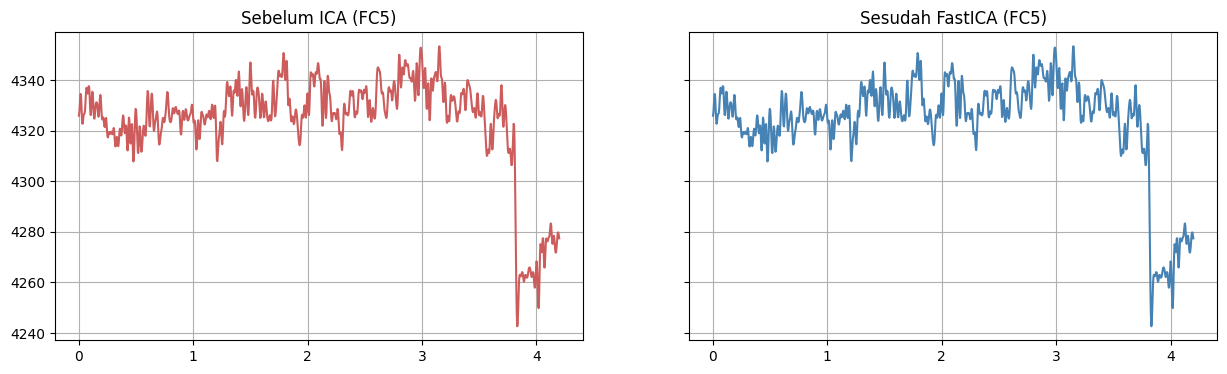

In [7]:
def apply_ica(eeg_signal, threshold=0.8):
    frontal_idx = [EEG_CHANNELS.index('EEG.AF3'), EEG_CHANNELS.index('EEG.AF4')]
    ica = FastICA(n_components=eeg_signal.shape[1], random_state=42, max_iter=1000)
    try:
        components = ica.fit_transform(eeg_signal)
        bad_components = []
        for i in range(components.shape[1]):
            for f_idx in frontal_idx:
                corr, _ = pearsonr(components[:, i], eeg_signal[:, f_idx])
                if abs(corr) > threshold: bad_components.append(i); break
        if bad_components: components[:, bad_components] = 0.0
        return ica.inverse_transform(components)
    except:
        return eeg_signal

clean_eeg = apply_ica(raw_eeg)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
af3_idx = EEG_CHANNELS.index('EEG.FC5')
waktu = np.arange(raw_eeg.shape[0]) / 256.0
axes[0].plot(waktu, raw_eeg[:, af3_idx], color='indianred'); axes[0].set_title("Sebelum ICA (FC5)")
axes[1].plot(waktu, clean_eeg[:, af3_idx], color='steelblue'); axes[1].set_title("Sesudah FastICA (FC5)")
plt.show()

Mengekstraksi IMF menggunakan CEEMDAN untuk seluruh 14 Channel (1076 sampel)... Mohon sabar.
Selesai! Jumlah IMF maksimum yang dihasilkan: 8
Plotting IMF Grid...


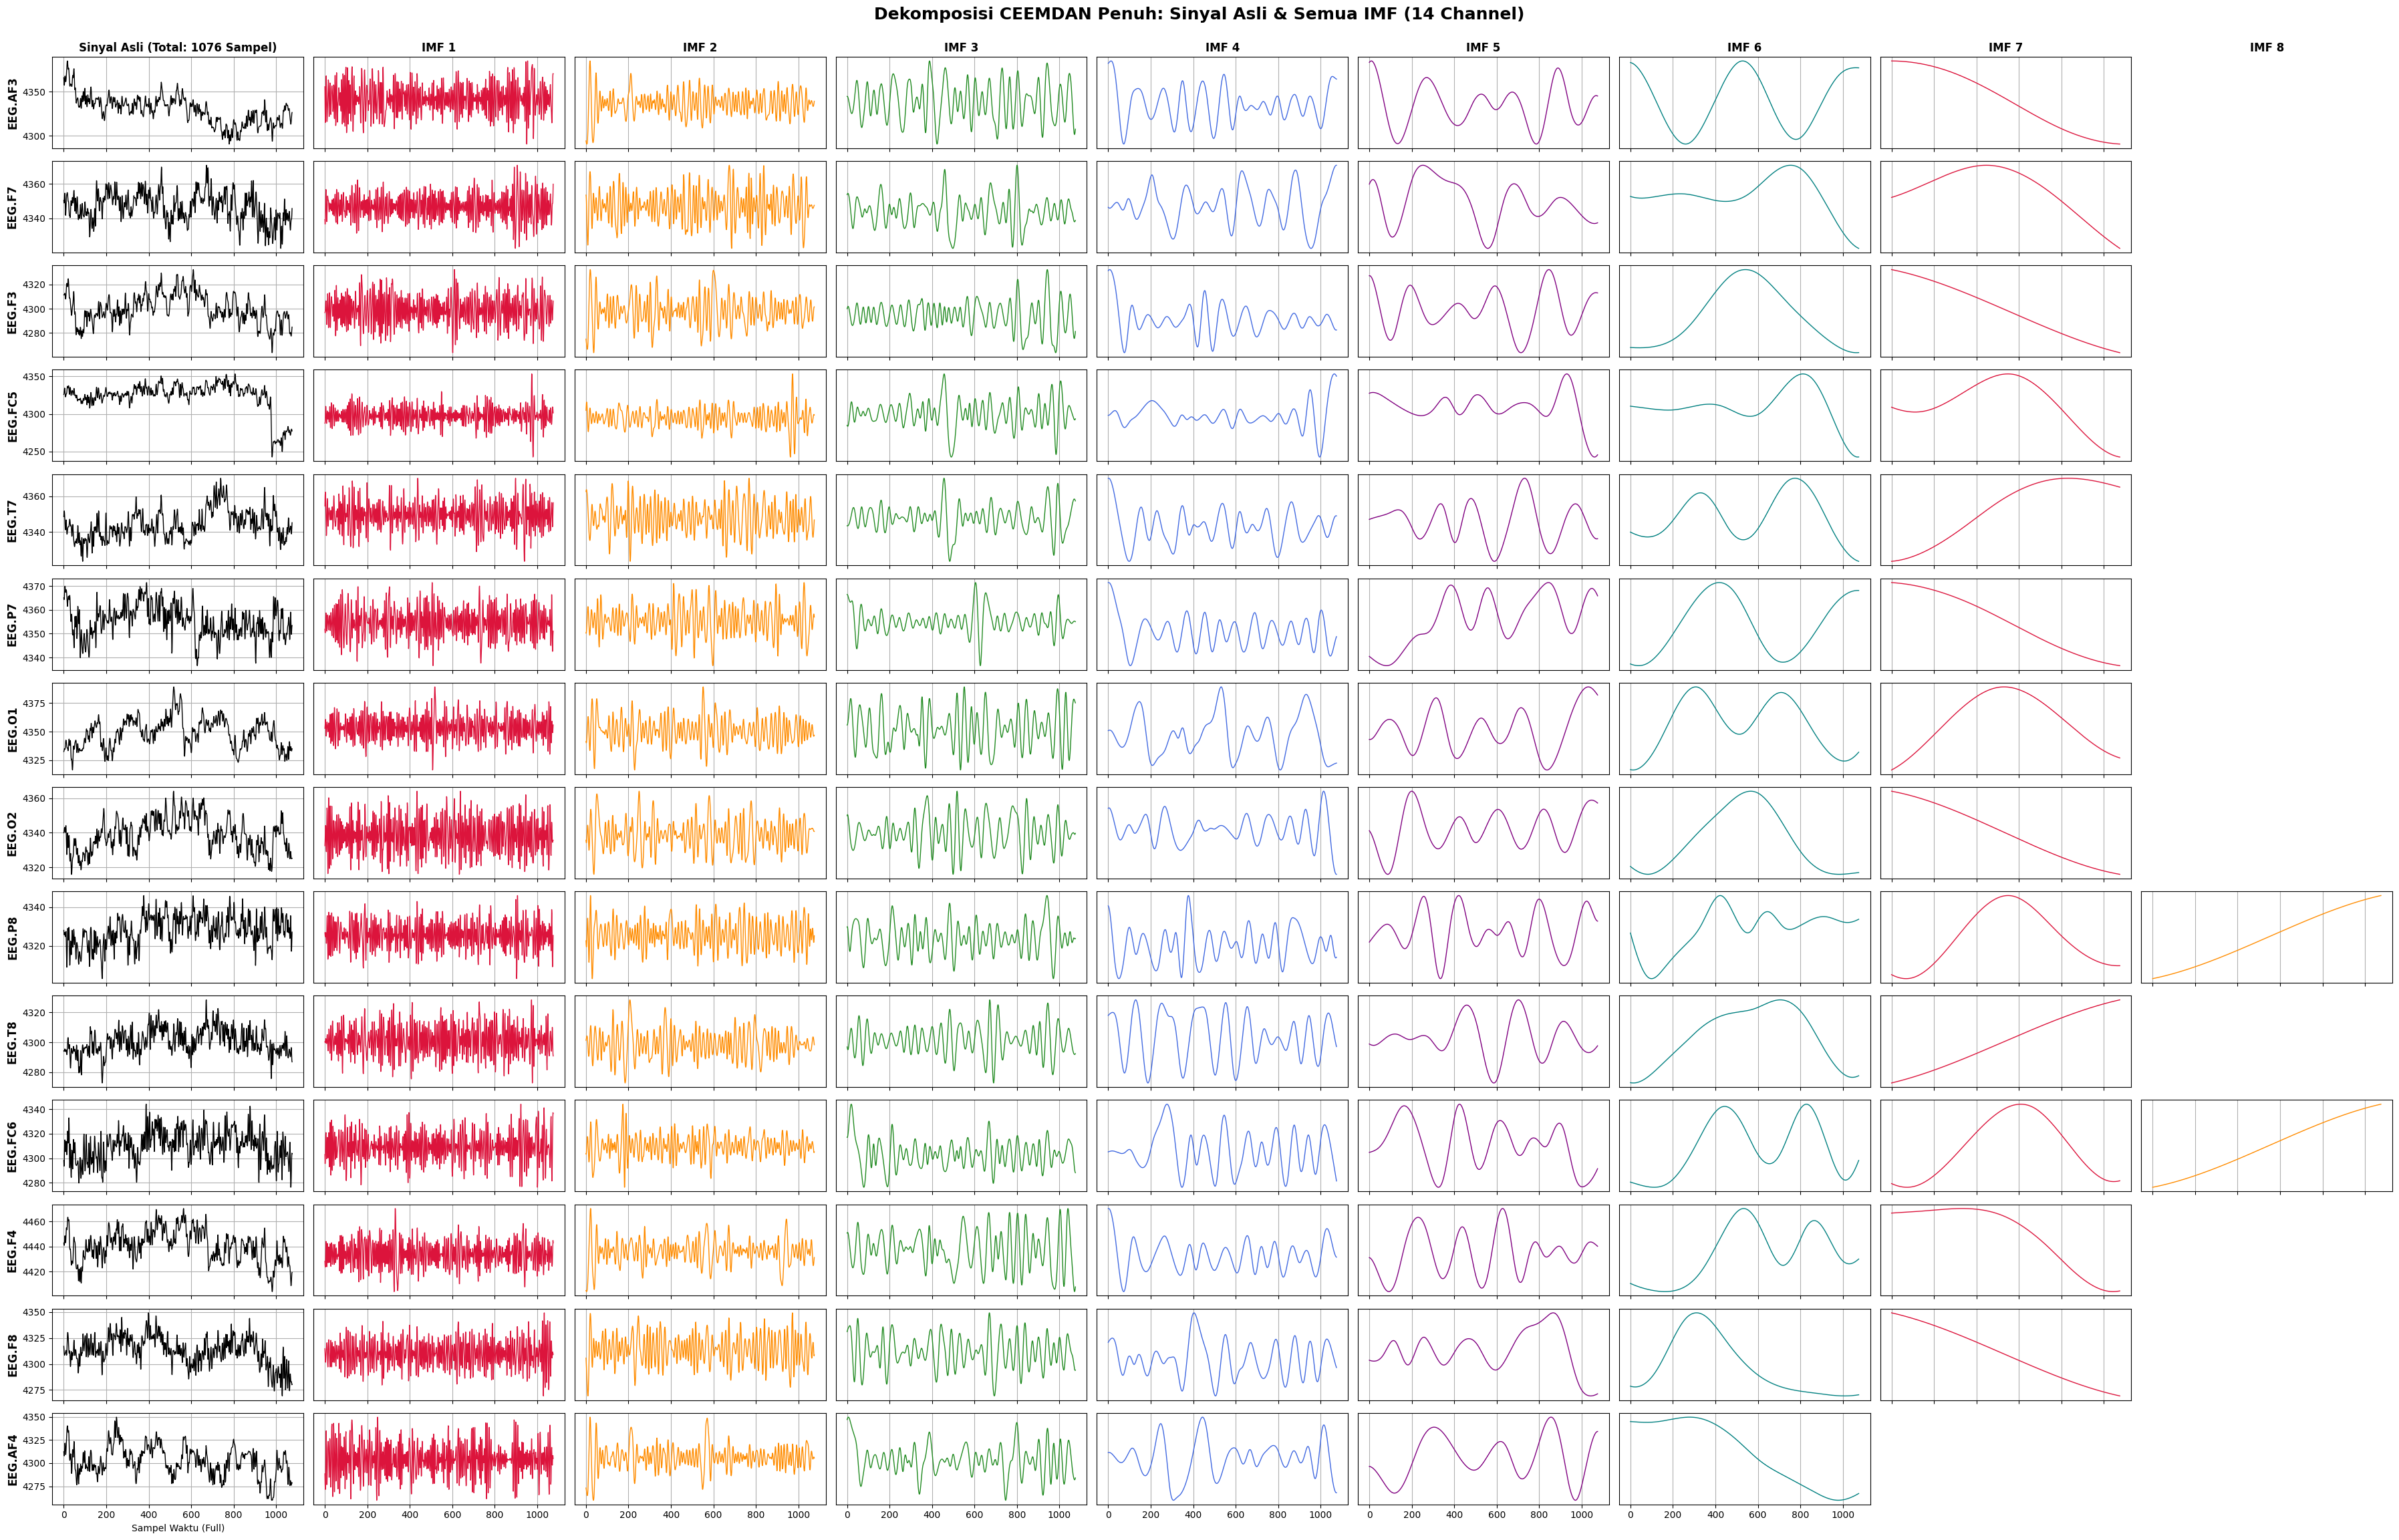


Memproses ekstraksi Hilbert Spectrum (Semua IMF, Durasi Penuh)... Mohon tunggu.
Shape Fitur Akhir (T_Frames, 910): (134, 910)


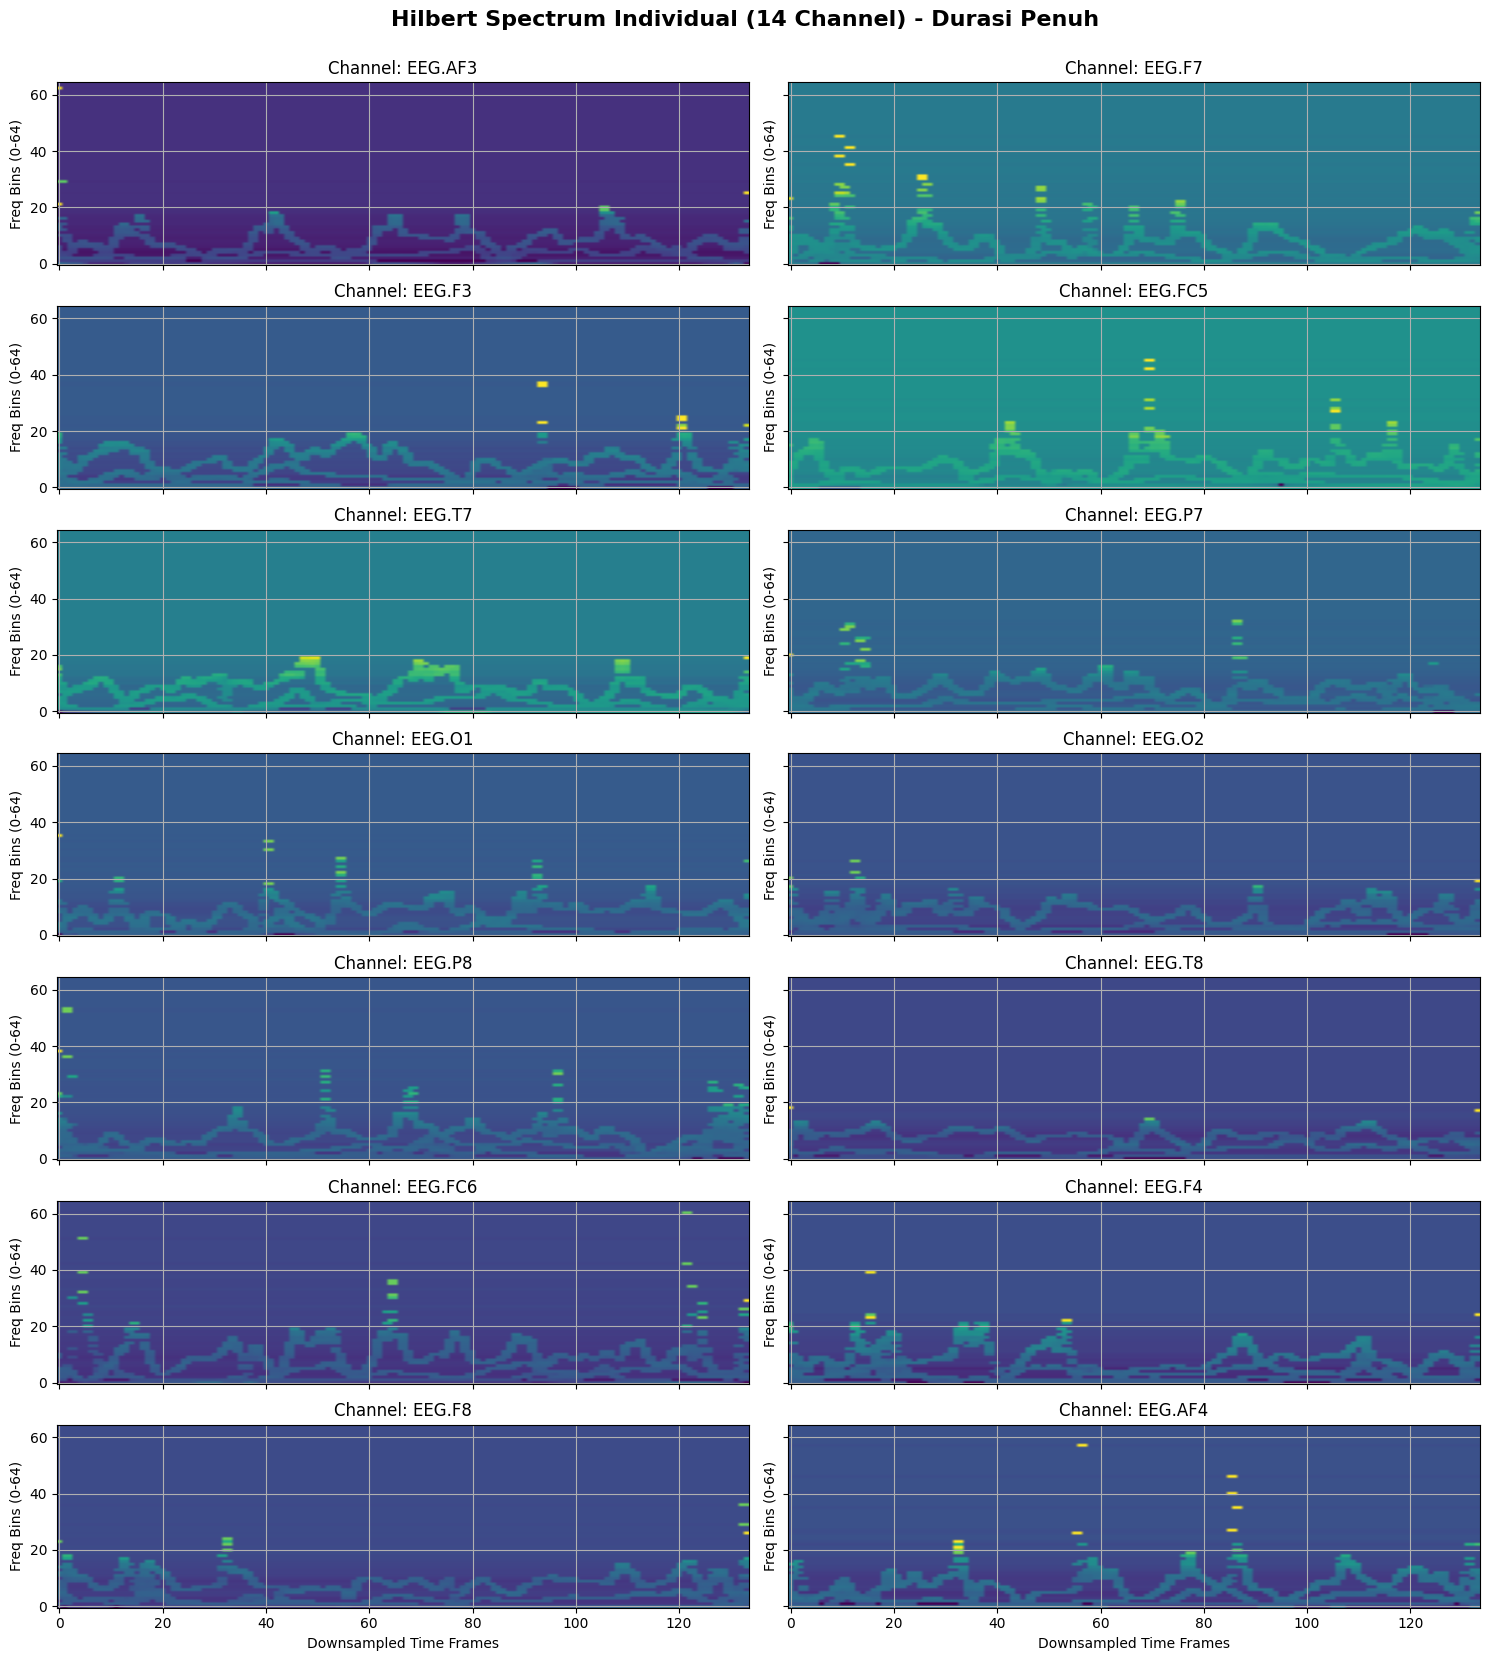

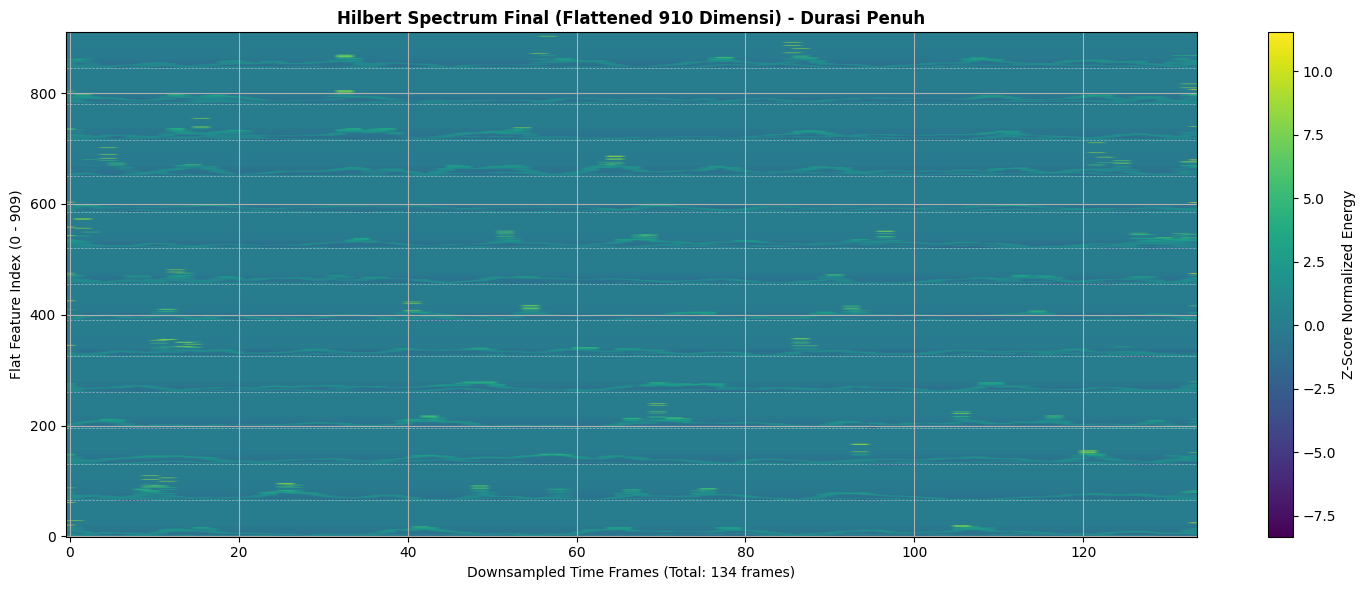

In [8]:
# ==============================================================================
# 1. CEEMDAN & VISUALISASI IMF PENUH UNTUK SELURUH 14 CHANNEL
# ==============================================================================
print(f"Mengekstraksi IMF menggunakan CEEMDAN untuk seluruh 14 Channel ({clean_eeg.shape[0]} sampel)... Mohon sabar.")

# Inisiasi CEEMDAN
ceemdan = CEEMDAN(trials=CONFIG['ceemdan_trials'], noise_scale=0.2, parallel=False)

# Siapkan list untuk menyimpan semua IMF
all_channels_imfs = []
max_imf_count_found = 0 # Menyimpan jumlah IMF terbanyak yang dihasilkan

for i in range(14):
    signal_ch = clean_eeg[:, i].astype(np.float64)
    # Ekstrak SEMUA IMF per channel (tanpa batas max_imf)
    imfs = ceemdan(signal_ch)
    
    # Update max_imf_count untuk kebutuhan plotting grid nanti
    if imfs.shape[0] > max_imf_count_found:
        max_imf_count_found = imfs.shape[0]
        
    all_channels_imfs.append((signal_ch, imfs))

print(f"Selesai! Jumlah IMF maksimum yang dihasilkan: {max_imf_count_found}")
print("Plotting IMF Grid...")

# Buat grid plot 14 Baris x (1 + max_imf_count_found) Kolom
fig, axes = plt.subplots(14, max_imf_count_found + 1, figsize=(4 * (max_imf_count_found + 1), 25), sharex=True)

# Warna-warni (cyclic) untuk membedakan IMF
imf_colors = ['crimson', 'darkorange', 'forestgreen', 'royalblue', 'purple', 'teal']

for row, (ch_name, (signal_ch, imfs)) in enumerate(zip(EEG_CHANNELS, all_channels_imfs)):
    # Kolom 0: Plot Sinyal Asli (Clean)
    axes[row, 0].plot(signal_ch, color='black', linewidth=1)
    axes[row, 0].set_ylabel(ch_name, fontweight='bold', fontsize=12)
    if row == 0: axes[row, 0].set_title(f"Sinyal Asli (Total: {len(signal_ch)} Sampel)", fontweight='bold')
    
    # Kolom 1 dst: Plot IMF
    actual_imf_count = imfs.shape[0]
    for col in range(max_imf_count_found):
        ax = axes[row, col + 1]
        if col < actual_imf_count:
            # Jika IMF ada, plot dengan warnanya
            ax.plot(imfs[col], color=imf_colors[col % len(imf_colors)], linewidth=1)
        else:
             # Jika channel ini menghasilkan IMF lebih sedikit dari maksimum
            ax.axis('off') # Sembunyikan axis yang kosong
            
        if row == 0: 
            ax.set_title(f"IMF {col+1}", fontweight='bold')
            
        ax.set_yticks([]) 
        
axes[13, 0].set_xlabel("Sampel Waktu (Full)")
plt.suptitle(f"Dekomposisi CEEMDAN Penuh: Sinyal Asli & Semua IMF (14 Channel)", 
             fontsize=18, fontweight='bold', y=0.92)
plt.tight_layout()
plt.subplots_adjust(top=0.89)
plt.show()

# ==============================================================================
# 2. EKSTRAKSI FITUR PENUH (14 CHANNEL) UNTUK MASUK KE MODEL
# ==============================================================================
# Fungsi disesuaikan untuk menggunakan SEMUA IMF dalam Hilbert Transform
def compute_hilbert_spectrum(eeg_signal, config):
    n_samples, n_channels = eeg_signal.shape
    fs = config['sample_rate']
    f_min, f_max, n_bins = config['f_min'], config['f_max'], config['n_freq_bins']
    hop_length, win_length = config['hop_length'], config['win_length']
    
    # Ambil nilai start_imf dari config (default 0 jika tidak diset)
    start_imf = config.get('start_imf', 0)
    
    freq_edges = np.linspace(f_min, f_max, n_bins + 1)
    ceemdan_local = CEEMDAN(trials=config['ceemdan_trials'], noise_scale=0.2, parallel=False)
    all_channel_spectra = []
    
    for ch_idx in range(n_channels):
        sig = eeg_signal[:, ch_idx].astype(np.float64)
        
        # Ekstrak semua IMF hingga akhir (residu)
        imfs = ceemdan_local(sig)
        
        # --- IMPLEMENTASI PEMOTONGAN START_IMF ---
        if start_imf < imfs.shape[0]:
            # Ambil dari indeks start_imf sampai indeks terakhir
            imfs = imfs[start_imf:]
        else:
            # Cegah error jika start_imf diset terlalu tinggi melebihi jumlah IMF
            # Kembalikan hanya IMF terakhir (residu)
            imfs = imfs[-1:]
            
        current_n_samples = n_samples
        hilbert_spec = np.zeros((n_bins, n_samples))
        
        # Akumulasi energi hanya dari IMF yang sudah disaring
        for i in range(imfs.shape[0]):
            analytic = hilbert(imfs[i])
            amp, phase = np.abs(analytic), np.unwrap(np.angle(analytic))
            freq = np.insert((np.diff(phase) / (2.0*np.pi) * fs), 0, 0)
            
            bin_indices = np.digitize(freq, freq_edges) - 1
            for t in range(n_samples):
                b = bin_indices[t]
                if 0 <= b < n_bins: 
                    hilbert_spec[b, t] += (amp[t] ** 2)
        
        # Padding & Windowing (Downsampling Waktu)
        if current_n_samples > win_length:
            rem = (current_n_samples - win_length) % hop_length
            if rem > 0:
                pad = hop_length - rem
                hilbert_spec = np.pad(hilbert_spec, ((0, 0), (0, pad)), mode='constant')
                current_n_samples += pad
                
        n_frames = 1 + (current_n_samples - win_length) // hop_length
        framed_spec = np.zeros((n_bins, n_frames))
        for t_idx in range(n_frames):
            start = t_idx * hop_length
            framed_spec[:, t_idx] = np.mean(hilbert_spec[:, start:start+win_length], axis=1)
        
        all_channel_spectra.append(framed_spec)
        
    all_channel_spectra = np.array(all_channel_spectra).transpose(2, 0, 1)
    features_flat = np.log(all_channel_spectra.reshape(all_channel_spectra.shape[0], -1) + 1e-9)
    return ((features_flat - np.mean(features_flat, axis=0)) / (np.std(features_flat, axis=0) + 1e-6)).astype(np.float32)

print("\nMemproses ekstraksi Hilbert Spectrum (Semua IMF, Durasi Penuh)... Mohon tunggu.")
full_features = compute_hilbert_spectrum(clean_eeg, CONFIG)
print(f"Shape Fitur Akhir (T_Frames, 910): {full_features.shape}")

# ==============================================================================
# 3. VISUALISASI HILBERT SPECTRUM PER CHANNEL (1-14)
# ==============================================================================
features_3d = full_features.reshape(-1, 14, 65)

# Buat grid 7 Baris x 2 Kolom untuk 14 Channel
fig, axes = plt.subplots(7, 2, figsize=(15, 18), sharex=True, sharey=True)
axes = axes.flatten()

for i, ch_name in enumerate(EEG_CHANNELS):
    # Transpose agar sumbu Y = Frekuensi (65), sumbu X = Waktu (T_Frames)
    spec_channel = features_3d[:, i, :].T
    
    im = axes[i].imshow(spec_channel, aspect='auto', origin='lower', cmap='viridis')
    axes[i].set_title(f"Channel: {ch_name}")
    axes[i].set_ylabel("Freq Bins (0-64)")
    if i >= 12: 
        axes[i].set_xlabel("Downsampled Time Frames")

plt.suptitle("Hilbert Spectrum Individual (14 Channel) - Durasi Penuh", fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# ==============================================================================
# 4. VISUALISASI FITUR AKHIR GABUNGAN (910 DIMENSI)
# ==============================================================================
plt.figure(figsize=(15, 6))
im_final = plt.imshow(full_features.T, aspect='auto', origin='lower', cmap='viridis')

plt.title("Hilbert Spectrum Final (Flattened 910 Dimensi) - Durasi Penuh", fontweight='bold')
plt.xlabel(f"Downsampled Time Frames (Total: {full_features.shape[0]} frames)")
plt.ylabel("Flat Feature Index (0 - 909)")
plt.colorbar(im_final, label="Z-Score Normalized Energy")

for i in range(1, 14):
    plt.axhline(y=i*65, color='white', linestyle='--', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Jumlah Frame Input (dari Hilbert Spectrum) : {feature_tensor.shape[1]}")
print(f"Jumlah Frame Output (yang dipakai Decoder) : {enc_out_lengths[0].item()}")

NameError: name 'feature_tensor' is not defined

In [10]:
import torch.optim as optim
import torchaudio.functional as F_audio

# ==============================================================================
# 1. INSTANSIASI TOKENIZER & TAMPILKAN VOCABULARY
# ==============================================================================
print("1. Menggunakan modul 'CharTokenizer'...")
tokenizer = CharTokenizer(transcripts=[target_sentence])
CONFIG['vocab_size'] = tokenizer.vocab_size()

print(f"   -> Kalimat Asli  : '{target_sentence}'")
print(f"   -> Target Int    : {tokenizer.text_to_int(target_sentence)}")
print(f"   -> Vocab Size    : {CONFIG['vocab_size']}")

print("\n--- DAFTAR VOCABULARY ---")
for i in range(CONFIG['vocab_size']):
    # Token 0 adalah sakral untuk <blank> pada RNN-T
    char_str = '<blank> (Jeda/Kosong)' if i == 0 else tokenizer.int_to_text([i])
    print(f"  ID {i}: {char_str}")

# ==============================================================================
# 2. PERSIAPAN MODEL & TENSOR UNTUK PELATIHAN
# ==============================================================================
print("\n2. Membangun arsitektur 'ConformerTransducer' & Persiapan Tensor...")
device = torch.device('cpu') # Gunakan CPU untuk demo 1 sampel agar mudah
model = ConformerTransducer(CONFIG).to(device)

# Siapkan input Tensor (Shape: Batch, Time, Features)
feature_tensor = torch.FloatTensor(  ).unsqueeze(0).to(device)
feature_length = torch.IntTensor([full_features.shape[0]]).to(device)

# Siapkan target Tensor (Shape: Batch, Target_Length)
target_ints = tokenizer.text_to_int(target_sentence)
target_tensor = torch.LongTensor([target_ints]).to(device)
target_length = torch.IntTensor([len(target_ints)]).to(device)

1. Menggunakan modul 'CharTokenizer'...
   -> Kalimat Asli  : 'siapa wanita itu'
   -> Target Int    : [6, 3, 2, 5, 2, 1, 9, 2, 4, 3, 7, 2, 1, 3, 7, 8]
   -> Vocab Size    : 10

--- DAFTAR VOCABULARY ---
  ID 0: <blank> (Jeda/Kosong)
  ID 1:  
  ID 2: a
  ID 3: i
  ID 4: n
  ID 5: p
  ID 6: s
  ID 7: t
  ID 8: u
  ID 9: w

2. Membangun arsitektur 'ConformerTransducer' & Persiapan Tensor...


In [11]:
# ==============================================================================
# VISUALISASI PERBANDINGAN: DENGAN SKALA WARNA (COLOR RANGE) YANG DISAMAKAN
# ==============================================================================

# 1. Persiapkan data seperti sebelumnya
num_segments = 20
win_len = CONFIG['win_length']
hop_len = CONFIG['hop_length']
max_samples_needed = (num_segments - 1) * hop_len + win_len

# Ambil Spektrum Mentah
raw_910_limited = get_raw_hilbert_910(clean_eeg[:max_samples_needed, :], CONFIG)
# Ambil 20 frame pertama dari fitur hasil segmentasi
segmented_20 = full_features[:num_segments, :].T 

# 2. HITUNG BATAS WARNA GLOBAL (VMIN & VMAX)
# Kita cari nilai terkecil dan terbesar dari kedua matriks agar skalanya identik
v_min = min(raw_910_limited.min(), segmented_20.min())
v_max = max(raw_910_limited.max(), segmented_20.max())

print(f"Batas Warna Disamakan -> Min: {v_min:.2f}, Max: {v_max:.2f}")

# 3. Visualisasi
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 12), gridspec_kw={'hspace': 0.3})

# --- PLOT A: SPEKTRUM MENTAH ---
# Tambahkan vmin dan vmax agar warna konsisten
im1 = ax1.imshow(raw_910_limited, aspect='auto', origin='lower', 
                 cmap='magma', vmin=v_min, vmax=v_max)
ax1.set_title(f"A. Spektrum Hilbert Mentah ({max_samples_needed} Sampel)", fontweight='bold')
ax1.set_ylabel("Fitur Index (0-909)")

for i in range(num_segments):
    start = i * hop_len
    rect = plt.Rectangle((start, 0), win_len, 910, 
                         edgecolor='cyan', facecolor='none', alpha=0.4, linewidth=1.5)
    ax1.add_patch(rect)

# --- PLOT B: HASIL SEGMENTASI ---
# Gunakan vmin dan vmax yang sama persis
im2 = ax2.imshow(segmented_20, aspect='auto', origin='lower', 
                 cmap='magma', vmin=v_min, vmax=v_max)
ax2.set_title(f"B. Hasil Akhir Segmentasi ({num_segments} Frame)", fontweight='bold')
ax2.set_ylabel("Fitur Index (0-909)")
ax2.set_xlabel("Indeks Frame (t)")

# Tambahkan satu Colorbar besar untuk kedua plot (karena skalanya sudah sama)
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(im2, cax=cbar_ax, label="Normalized Energy (Global Scale)")

# Garis pemisah channel
for ch_idx in range(1, 14):
    ax1.axhline(y=ch_idx * 65, color='white', linestyle='--', linewidth=0.5, alpha=0.3)
    ax2.axhline(y=ch_idx * 65, color='white', linestyle='--', linewidth=0.5, alpha=0.3)

plt.suptitle("Analisis Segmentasi dengan Skala Warna Konsisten", fontsize=18, fontweight='bold', y=0.96)
plt.show()

NameError: name 'get_raw_hilbert_910' is not defined

In [12]:
optimizer = optim.Adam(model.parameters(), lr=0.005) # Learning rate sedikit dibesarkan agar cepat overfit

# ==============================================================================
# 3. PELATIHAN (OVERFITTING PADA 1 SAMPEL - 10 EPOCH)
# ==============================================================================
print("\n3. Memulai Pelatihan (Sanity Check: 10 Epoch)...")
model.train()
EPOCH = 300
for epoch in range(1,EPOCH+1):
    optimizer.zero_grad()
    
    # Forward Pass sesuai logika all_train_1.py
    encoder_out = model.encoder(feature_tensor)
    
    blank_col = torch.zeros((1, 1), dtype=torch.long, device=device)
    decoder_input = torch.cat([blank_col, target_tensor], dim=1)
    hidden_state = model.decoder.init_hidden(1, device)
    decoder_out, _ = model.decoder(decoder_input, hidden_state)
    
    enc_proj = model.joiner.encoder_proj(encoder_out)
    dec_proj = model.joiner.decoder_proj(decoder_out)
    joint = enc_proj.unsqueeze(2) + dec_proj.unsqueeze(1)
    joint = model.joiner.activation(joint)
    logits = model.joiner.output_proj(joint)
    
    enc_out_lengths = model.get_encoder_out_lengths(feature_length)
    
    loss = F_audio.rnnt_loss(
        logits=logits, targets=target_tensor.to(torch.int32),
        logit_lengths=enc_out_lengths.to(torch.int32),
        target_lengths=target_length.to(torch.int32), blank=0
    )
    
    loss.backward()
    optimizer.step()
    
    print(f"  -> Epoch {epoch+1:02d}/{EPOCH} | RNN-T Loss: {loss.item():.4f}")

# ==============================================================================
# 4. PREDIKSI MENGGUNAKAN BEAM SEARCH DECODER
# ==============================================================================
print("\n4. Menjalankan Beam Search Decoding pada fitur yang diekstrak...")
model.eval()

beam_decoder = beam_decoder_char.BeamDecoderChar(
    model, tokenizer, beam_size=3, max_sym_per_frame=15
)

with torch.no_grad():
    pred_text = beam_decoder.decode(feature_tensor)

print("-" * 50)
print(f"TARGET TEKS   : {target_sentence}")
print(f"PREDIKSI MODEL: {pred_text}")
print("-" * 50)
if pred_text != target_sentence:
    print("*Catatan: Loss sudah menurun, namun 10 epoch mungkin belum cukup untuk model hafal 100% kalimat tersebut. Coba naikkan epoch jika ingin prediksi sempurna.")

# ==============================================================================
# 5. MENGINTIP PROBABILITAS DI DALAM BEAM DECODER (JOINT NETWORK)
# ==============================================================================
print("\n5. MENGINTIP PROBABILITAS TRANSDUCER (5 Frame Waktu Pertama)")
print("Pada State: u=0 (Model belum memprediksi huruf apapun, sedang menunggu)")

with torch.no_grad():
    # Recalculate logits untuk inference
    encoder_out = model.encoder(feature_tensor)
    hidden_state = model.decoder.init_hidden(1, device)
    
    # State awal u=0 (Input Decoder adalah <blank>)
    dec_input_blank = torch.zeros((1, 1), dtype=torch.long, device=device)
    decoder_out, _ = model.decoder(dec_input_blank, hidden_state)
    
    enc_proj = model.joiner.encoder_proj(encoder_out)
    dec_proj = model.joiner.decoder_proj(decoder_out)
    
    # Iterasi 5 frame pertama
    for t in range(5):
        if t >= enc_proj.shape[1]: break
            
        # Hitung Joint Probabilities untuk frame t
        # Shape enc_proj dan dec_proj di sini adalah (1, 1, Joint_dim)
        joint_t = enc_proj[:, t:t+1, :] + dec_proj
        joint_t = model.joiner.activation(joint_t)
        
        # Logits_t menghasilkan tensor 3 Dimensi: (Batch=1, Frame=1, Vocab_Size)
        logits_t = model.joiner.output_proj(joint_t) 
        
        # Mengambil probabilitas dengan 3 dimensi [Batch_0, Frame_0, Semua_Vocab]
        probs = torch.softmax(logits_t[0, 0, :], dim=-1) 
        
        # Ambil Top-3 Probabilitas
        top_probs, top_indices = torch.topk(probs, 3)
        
        print(f"\n[Frame Waktu t={t}] - Probabilitas Top 3:")
        for rank in range(3):
            token_idx = top_indices[rank].item()
            prob_val = top_probs[rank].item() * 100
            
            token_str = '<blank>' if token_idx == 0 else tokenizer.int_to_text([token_idx])
            print(f"  {rank+1}. '{token_str}' (ID: {token_idx}) -> {prob_val:.2f}%")


3. Memulai Pelatihan (Sanity Check: 10 Epoch)...


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 0]

In [13]:
# ==============================================================================
# 5. MENGINTIP JALUR PREDIKSI (SIMULASI GREEDY SEARCH PATH)
# ==============================================================================
print("\n5. MENGINTIP JALUR DECODING (GREEDY PATH TRANSDUCER)")
print("Kita akan mengikuti langkah model menyusuri grid T (Waktu) dan U (Teks).\n")

with torch.no_grad():
    encoder_out = model.encoder(feature_tensor)
    
    # Inisialisasi State Awal (Pojok Kiri Atas Grid: t=0, u=0)
    t = 0
    u = 0
    max_t = encoder_out.shape[1]
    
    # Input awal untuk decoder selalu <blank> (ID: 0)
    current_decoder_input = torch.zeros((1, 1), dtype=torch.long, device=device)
    hidden_state = model.decoder.init_hidden(1, device)
    
    pred_tokens = []
    max_steps = 20 # Batasi jumlah log yang dicetak agar tidak terlalu panjang
    step = 1
    
    while t < max_t and step <= max_steps:
        # 1. Jalankan Decoder untuk mendapatkan memori teks sejauh ini
        # Penting: Kita simpan next_hidden_state, tapi HANYA di-apply jika model mencetak huruf!
        decoder_out, next_hidden_state = model.decoder(current_decoder_input, hidden_state)
        
        # 2. Gabungkan keyakinan Encoder (t) dan Decoder (u)
        enc_proj = model.joiner.encoder_proj(encoder_out[:, t:t+1, :]) # Shape: [1, 1, Dim]
        dec_proj = model.joiner.decoder_proj(decoder_out)              # Shape: [1, 1, Dim]
        
        joint = enc_proj + dec_proj
        joint = model.joiner.activation(joint)
        logits = model.joiner.output_proj(joint) # Shape: [1, 1, Vocab_Size]
        
        # 3. Hitung Probabilitas
        probs = torch.softmax(logits[0, 0, :], dim=-1) 
        top_probs, top_indices = torch.topk(probs, 3)
        
        best_idx = top_indices[0].item()
        best_prob = top_probs[0].item() * 100
        
        current_text = "".join([tokenizer.int_to_text([idx]) for idx in pred_tokens])
        
        print(f"Langkah {step} | [Waktu t={t}, Teks u={u}] | Teks Terbentuk: '{current_text}'")
        print("  Top 3 Prediksi:")
        for rank in range(3):
            token_idx = top_indices[rank].item()
            prob_val = top_probs[rank].item() * 100
            token_str = '<blank>' if token_idx == 0 else tokenizer.int_to_text([token_idx])
            print(f"    {rank+1}. '{token_str}' (ID: {token_idx}) -> {prob_val:.2f}%")
            
        # 4. Ambil Keputusan (Aksi Berdasarkan Probabilitas Tertinggi)
        if best_idx == 0:
            print("  -> AKSI: Mengeluarkan <blank>. Waktu (t) maju +1. Teks (u) tetap.")
            # State memori Decoder (LSTM) TIDAK berubah jika prediksi <blank>
            t += 1
        else:
            char_pred = tokenizer.int_to_text([best_idx])
            print(f"  -> AKSI: Mencetak huruf '{char_pred}'. Teks (u) maju +1. Waktu (t) tetap!")
            pred_tokens.append(best_idx)
            u += 1
            # Update input dan State memori Decoder untuk langkah selanjutnya
            current_decoder_input = torch.tensor([[best_idx]], dtype=torch.long, device=device)
            hidden_state = next_hidden_state 
            
        print("-" * 65)
        step += 1
        
        if len(pred_tokens) >= len(target_sentence) + 5: 
            break # Berhenti jika kalimat sudah terbentuk untuk menghemat log


5. MENGINTIP JALUR DECODING (GREEDY PATH TRANSDUCER)
Kita akan mengikuti langkah model menyusuri grid T (Waktu) dan U (Teks).



RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 0]